# Compare Stock Forecasting Results

This notebook scans the training outputs under `artifacts/`, builds leaderboards across models, horizons, and modalities, and generates presentation-ready plots and talking points.

It is designed to answer four competition-style questions:

1. Which run is best overall?
2. Which model is best for each horizon?
3. Does adding news and sentiment help?
4. Which result is both strong and robust enough to present with confidence?


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
    HAVE_SEABORN = True
except ImportError:
    HAVE_SEABORN = False
    plt.style.use("seaborn-v0_8-whitegrid")

RESULTS_ROOT = Path("artifacts")
FALLBACK_SEARCH_ROOT = Path(".")
SELECTED_TASK = "regression"  # recommended default when you have mixed task runs
TOP_N = 12
MANUAL_BEST_RUN = None  # set to a run name to override the auto-selected best run

pd.options.display.max_columns = 200
pd.options.display.float_format = lambda x: f"{x:,.4f}"

from stock_forecasting.visualization import (
    plot_random_stock_candlestick_forecasts,
    plot_random_stock_history_forecasts,
)


In [2]:
REGRESSION_RULES = [
    ("test_daily_spearman_ic_mean", 1.60, 1),
    ("test_spearman_ic", 1.10, 1),
    ("test_directional_accuracy", 0.90, 1),
    ("test_top_bottom_decile_spread", 1.00, 1),
    ("test_rmse", 0.85, -1),
    ("test_mae", 0.60, -1),
]

CLASSIFICATION_RULES = [
    ("test_balanced_accuracy", 1.60, 1),
    ("test_f1", 1.20, 1),
    ("test_accuracy", 0.90, 1),
    ("test_precision", 0.60, 1),
    ("test_recall", 0.60, 1),
]


def discover_run_dirs(results_root=RESULTS_ROOT):
    if results_root.exists():
        summary_paths = list(results_root.rglob("summary.csv"))
    else:
        summary_paths = []

    if not summary_paths:
        summary_paths = [
            path for path in FALLBACK_SEARCH_ROOT.rglob("summary.csv")
            if "artifacts" in path.parts
        ]

    run_dirs = []
    for summary_path in summary_paths:
        run_dir = summary_path.parent
        if (run_dir / "config.json").exists():
            run_dirs.append(run_dir)
    return sorted(set(run_dirs))


def load_json(path):
    with open(path, "r", encoding="utf-8") as handle:
        return json.load(handle)


def main_metric_for_task(task, frame):
    candidates = [
        "test_daily_spearman_ic_mean",
        "test_balanced_accuracy",
        "test_spearman_ic",
        "test_f1",
        "test_directional_accuracy",
        "test_accuracy",
    ]
    task_specific = [
        "test_balanced_accuracy", "test_f1", "test_accuracy"
    ] if task == "classification" else [
        "test_daily_spearman_ic_mean", "test_spearman_ic", "test_directional_accuracy"
    ]
    for column in task_specific + candidates:
        if column in frame.columns:
            return column
    numeric_cols = frame.select_dtypes(include="number").columns.tolist()
    return numeric_cols[0] if numeric_cols else None


def zscore(series):
    series = pd.to_numeric(series, errors="coerce")
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


def load_results(run_dirs):
    run_rows = []
    fold_frames = []

    for run_dir in run_dirs:
        config = load_json(run_dir / "config.json")
        fold_df = pd.read_csv(run_dir / "summary.csv")
        numeric_cols = fold_df.select_dtypes(include="number").columns.tolist()

        run_row = {
            "run_name": run_dir.name,
            "run_dir": str(run_dir),
            "model_name": config.get("model_name"),
            "modalities": config.get("modalities"),
            "task": config.get("task"),
            "horizon": config.get("horizon"),
            "lookback": config.get("lookback"),
            "news_lag_days": config.get("news_lag_days"),
            "seed": config.get("seed"),
            "eval_mode": config.get("eval_mode"),
            "price_csv": config.get("price_csv"),
            "news_csv": config.get("news_csv"),
            "fold_count": len(fold_df),
        }
        for column in numeric_cols:
            run_row[column] = fold_df[column].mean()
            run_row[f"{column}__std"] = fold_df[column].std(ddof=0)
        run_rows.append(run_row)

        if not fold_df.empty:
            fold_frames.append(
                fold_df.assign(
                    run_name=run_dir.name,
                    run_dir=str(run_dir),
                    model_name=config.get("model_name"),
                    modalities=config.get("modalities"),
                    task=config.get("task"),
                    horizon=config.get("horizon"),
                    lookback=config.get("lookback"),
                    news_lag_days=config.get("news_lag_days"),
                    seed=config.get("seed"),
                    eval_mode=config.get("eval_mode"),
                    price_csv=config.get("price_csv"),
                    news_csv=config.get("news_csv"),
                )
            )

    runs_df = pd.DataFrame(run_rows)
    folds_df = pd.concat(fold_frames, ignore_index=True) if fold_frames else pd.DataFrame()
    return runs_df, folds_df


def rank_runs(runs_df):
    if runs_df.empty:
        return runs_df.copy(), None

    task = runs_df["task"].mode().iloc[0] if "task" in runs_df.columns and not runs_df["task"].dropna().empty else "regression"
    rules = CLASSIFICATION_RULES if task == "classification" else REGRESSION_RULES
    main_metric = main_metric_for_task(task, runs_df)

    ranked = runs_df.copy()
    composite = pd.Series(np.zeros(len(ranked)), index=ranked.index, dtype=float)
    used_columns = []
    for column, weight, direction in rules:
        if column in ranked.columns:
            column_score = zscore(ranked[column]).fillna(0.0)
            if direction < 0:
                column_score = -column_score
            composite = composite + weight * column_score
            used_columns.append(column)

    if main_metric and f"{main_metric}__std" in ranked.columns:
        composite = composite - 0.35 * zscore(ranked[f"{main_metric}__std"]).fillna(0.0)

    ranked["composite_score"] = composite
    ranked["main_metric"] = main_metric
    ranked["used_metric_count"] = len(used_columns)
    ranked = ranked.sort_values(["composite_score", main_metric], ascending=[False, False], na_position="last")
    return ranked.reset_index(drop=True), main_metric


def load_predictions_for_run(run_name, runs_df):
    if runs_df.empty or run_name is None:
        return pd.DataFrame()
    row = runs_df.loc[runs_df["run_name"] == run_name]
    if row.empty:
        return pd.DataFrame()
    run_dir = Path(row.iloc[0]["run_dir"])
    frames = []
    for prediction_path in sorted(run_dir.glob("*/test_predictions.csv")):
        frame = pd.read_csv(prediction_path, parse_dates=["date"])
        frame["fold"] = prediction_path.parent.name
        frame["run_name"] = run_name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def build_prediction_diagnostics(predictions_df):
    if predictions_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    frame = predictions_df.copy()
    frame["abs_error"] = (frame["prediction"] - frame["target"]).abs()
    frame["direction_hit"] = ((frame["prediction"] > 0) == (frame["target"] > 0)).astype(float)

    daily_rows = []
    for date, group in frame.groupby("date"):
        if len(group) < 5:
            continue
        bucket = max(1, len(group) // 10)
        ordered = group.sort_values("prediction")
        try:
            daily_ic = group["prediction"].corr(group["target"], method="spearman")
        except Exception:
            daily_ic = np.nan
        daily_rows.append(
            {
                "date": date,
                "daily_ic": daily_ic,
                "top_bottom_spread": ordered["target"].tail(bucket).mean() - ordered["target"].head(bucket).mean(),
                "directional_accuracy": group["direction_hit"].mean(),
                "mean_abs_error": group["abs_error"].mean(),
                "sample_count": len(group),
            }
        )
    daily_df = pd.DataFrame(daily_rows).sort_values("date") if daily_rows else pd.DataFrame()
    if not daily_df.empty:
        daily_df["cumulative_spread"] = daily_df["top_bottom_spread"].fillna(0.0).cumsum()
        daily_df["rolling_ic_20"] = daily_df["daily_ic"].rolling(20, min_periods=5).mean()

    ticker_df = (
        frame.groupby("ticker")
        .agg(
            observations=("ticker", "size"),
            mean_abs_error=("abs_error", "mean"),
            directional_accuracy=("direction_hit", "mean"),
            prediction_mean=("prediction", "mean"),
            target_mean=("target", "mean"),
        )
        .reset_index()
        .sort_values(["directional_accuracy", "mean_abs_error"], ascending=[False, True])
    )

    magnitude_df = pd.DataFrame()
    if frame["target"].notna().sum() > 10:
        tmp = frame.copy()
        tmp["target_magnitude"] = tmp["target"].abs()
        bucket_count = min(5, tmp["target_magnitude"].nunique())
        if bucket_count >= 2:
            tmp["magnitude_bucket"] = pd.qcut(tmp["target_magnitude"], q=bucket_count, duplicates="drop")
            magnitude_df = (
                tmp.groupby("magnitude_bucket")
                .agg(
                    mean_abs_error=("abs_error", "mean"),
                    directional_accuracy=("direction_hit", "mean"),
                    avg_target_magnitude=("target_magnitude", "mean"),
                    observations=("target_magnitude", "size"),
                )
                .reset_index()
            )

    return daily_df, ticker_df, magnitude_df


In [3]:
run_dirs = discover_run_dirs()
runs_df, folds_df = load_results(run_dirs)

if runs_df.empty:
    display(Markdown("## No completed results found yet\nRun the training suite first, then re-open this notebook."))
else:
    if SELECTED_TASK is not None and "task" in runs_df.columns:
        analysis_df = runs_df.loc[runs_df["task"] == SELECTED_TASK].copy()
        analysis_folds_df = folds_df.loc[folds_df["task"] == SELECTED_TASK].copy() if not folds_df.empty else folds_df.copy()
    else:
        analysis_df = runs_df.copy()
        analysis_folds_df = folds_df.copy()

    ranked_df, MAIN_METRIC = rank_runs(analysis_df)
    display(Markdown(f"## Discovered {len(ranked_df)} completed runs"))
    display(ranked_df[["run_name", "model_name", "modalities", "horizon", "task", "fold_count", "composite_score", MAIN_METRIC]].head(TOP_N))

    overview = ranked_df.groupby(["model_name", "modalities", "horizon"]).size().reset_index(name="run_count")
    display(Markdown("### Coverage by model, modality, and horizon"))
    display(overview)

    if {"model_name", "horizon", "lookback", "news_lag_days"}.issubset(ranked_df.columns):
        sensitivity_overview = (
            ranked_df.groupby(["model_name", "horizon"])
            .agg(
                lookback_count=("lookback", "nunique"),
                news_lag_count=("news_lag_days", "nunique"),
                seed_count=("seed", "nunique"),
            )
            .reset_index()
        )
        display(Markdown("### Coverage by tuning dimensions"))
        display(sensitivity_overview)


## Discovered 14 completed runs

,run_name,model_name,modalities,horizon,task,fold_count,composite_score,test_daily_spearman_ic_mean
0,timexer_h1_price_news_regression_lb60_lag1_wal...,timexer,price_news,1,regression,2,6.8025,0.0412
1,timexer_h1_price_news_regression_lb30_lag2_wal...,timexer,price_news,1,regression,3,6.1720,0.0340
2,lstm_h1_price_regression_lb20_lag1_walkforward_s7,lstm,price,1,regression,4,2.0110,0.0037
3,hf_patchtst_h1_price_news_regression_lb30_lag2...,hf_patchtst,price_news,1,regression,3,1.6944,0.0297
4,timexer_h1_price_news_regression_lb30_lag1_wal...,timexer,price_news,1,regression,3,0.8373,0.0087
5,hf_patchtst_h1_price_news_regression_lb30_lag1...,hf_patchtst,price_news,1,regression,3,0.4036,0.0048
6,timexer_h1_price_news_regression_lb60_lag2_wal...,timexer,price_news,1,regression,2,-0.3260,-0.0083
7,hf_patchtst_h5_price_news_regression_lb60_lag1...,hf_patchtst,price_news,5,regression,1,-0.3647,0.0114
8,timexer_h5_price_news_regression_lb60_lag1_wal...,timexer,price_news,5,regression,1,-1.1058,-0.0082
9,lightgbm_h1_price_regression_lb20_lag1_walkfor...,lightgbm,price,1,regression,4,-2.0209,-0.0179


### Coverage by model, modality, and horizon

,model_name,modalities,horizon,run_count
0,hf_patchtst,price_news,1,4
1,hf_patchtst,price_news,5,2
2,lightgbm,price,1,1
3,lstm,price,1,1
4,timexer,price_news,1,4
5,timexer,price_news,5,2


### Coverage by tuning dimensions

,model_name,horizon,lookback_count,news_lag_count,seed_count
0,hf_patchtst,1,2,2,1
1,hf_patchtst,5,1,2,1
2,lightgbm,1,1,1,1
3,lstm,1,1,1,1
4,timexer,1,2,2,1
5,timexer,5,1,2,1


## Leaderboards

The composite score combines predictive quality and robustness. It is not a replacement for the raw metrics, but it is useful for deciding which run is strongest overall for a demo or competition presentation.

In [4]:
if not runs_df.empty:
    leaderboard_columns = [
        "run_name", "model_name", "modalities", "horizon", "lookback", "news_lag_days", "seed", "fold_count",
        "composite_score", MAIN_METRIC
    ]
    optional_columns = [
        "test_directional_accuracy", "test_rmse", "test_mae", "test_top_bottom_decile_spread",
        "test_balanced_accuracy", "test_f1"
    ]
    leaderboard_columns.extend([column for column in optional_columns if column in ranked_df.columns])
    display(Markdown("### Top runs overall"))
    display(ranked_df[leaderboard_columns].head(TOP_N))

    best_by_horizon = (
        ranked_df.sort_values("composite_score", ascending=False)
        .groupby("horizon", as_index=False)
        .head(1)
        .sort_values("horizon")
    )
    display(Markdown("### Best run by horizon"))
    display(best_by_horizon[["horizon", "run_name", "model_name", "modalities", MAIN_METRIC, "composite_score"]])

    best_by_model = (
        ranked_df.sort_values("composite_score", ascending=False)
        .groupby("model_name", as_index=False)
        .head(1)
        .sort_values("composite_score", ascending=False)
    )
    display(Markdown("### Best run per model family"))
    display(best_by_model[["model_name", "run_name", "modalities", "horizon", MAIN_METRIC, "composite_score"]])


### Top runs overall

,run_name,model_name,modalities,horizon,lookback,news_lag_days,seed,fold_count,composite_score,test_daily_spearman_ic_mean,test_directional_accuracy,test_rmse,test_mae,test_top_bottom_decile_spread
0,timexer_h1_price_news_regression_lb60_lag1_wal...,timexer,price_news,1,60,1,7,2,6.8025,0.0412,0.5132,0.0189,0.0124,0.0025
1,timexer_h1_price_news_regression_lb30_lag2_wal...,timexer,price_news,1,30,2,7,3,6.1720,0.0340,0.5261,0.0179,0.0117,0.0022
2,lstm_h1_price_regression_lb20_lag1_walkforward_s7,lstm,price,1,20,1,7,4,2.0110,0.0037,0.5251,0.0199,0.0130,0.0004
3,hf_patchtst_h1_price_news_regression_lb30_lag2...,hf_patchtst,price_news,1,30,2,7,3,1.6944,0.0297,0.4994,0.0181,0.0118,0.0017
4,timexer_h1_price_news_regression_lb30_lag1_wal...,timexer,price_news,1,30,1,7,3,0.8373,0.0087,0.5269,0.0179,0.0116,0.0007
5,hf_patchtst_h1_price_news_regression_lb30_lag1...,hf_patchtst,price_news,1,30,1,7,3,0.4036,0.0048,0.5109,0.0180,0.0118,0.0009
6,timexer_h1_price_news_regression_lb60_lag2_wal...,timexer,price_news,1,60,2,7,2,-0.3260,-0.0083,0.5135,0.0189,0.0123,0.0006
7,hf_patchtst_h5_price_news_regression_lb60_lag1...,hf_patchtst,price_news,5,60,1,7,1,-0.3647,0.0114,0.5107,0.0355,0.0252,0.0017
8,timexer_h5_price_news_regression_lb60_lag1_wal...,timexer,price_news,5,60,1,7,1,-1.1058,-0.0082,0.5570,0.0345,0.0248,-0.0021
9,lightgbm_h1_price_regression_lb20_lag1_walkfor...,lightgbm,price,1,20,1,7,4,-2.0209,-0.0179,0.5345,0.0199,0.0130,-0.0003


### Best run by horizon

,horizon,run_name,model_name,modalities,test_daily_spearman_ic_mean,composite_score
0,1,timexer_h1_price_news_regression_lb60_lag1_wal...,timexer,price_news,0.0412,6.8025
7,5,hf_patchtst_h5_price_news_regression_lb60_lag1...,hf_patchtst,price_news,0.0114,-0.3647


### Best run per model family

,model_name,run_name,modalities,horizon,test_daily_spearman_ic_mean,composite_score
0,timexer,timexer_h1_price_news_regression_lb60_lag1_wal...,price_news,1,0.0412,6.8025
2,lstm,lstm_h1_price_regression_lb20_lag1_walkforward_s7,price,1,0.0037,2.0110
3,hf_patchtst,hf_patchtst_h1_price_news_regression_lb30_lag2...,price_news,1,0.0297,1.6944
9,lightgbm,lightgbm_h1_price_regression_lb20_lag1_walkfor...,price,1,-0.0179,-2.0209


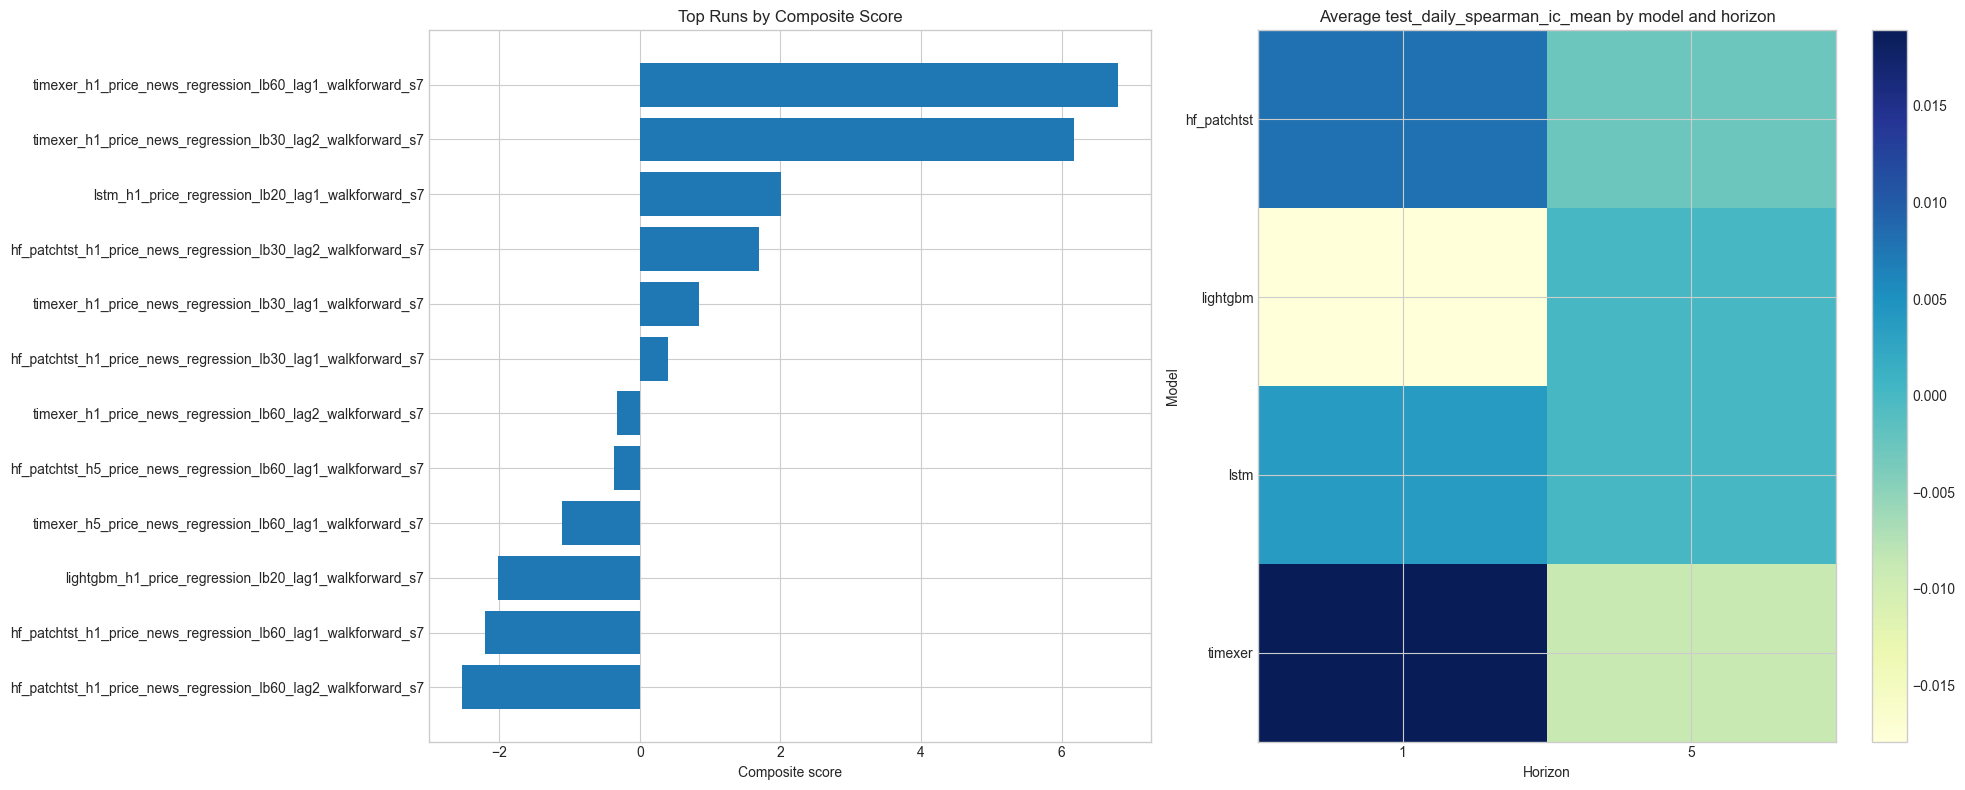

In [5]:
if not runs_df.empty:
    top_plot_df = ranked_df.head(TOP_N).sort_values("composite_score")
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    axes[0].barh(top_plot_df["run_name"], top_plot_df["composite_score"], color="#1f77b4")
    axes[0].set_title("Top Runs by Composite Score")
    axes[0].set_xlabel("Composite score")

    heatmap_df = ranked_df.pivot_table(index="model_name", columns="horizon", values=MAIN_METRIC, aggfunc="mean")
    if HAVE_SEABORN:
        sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1])
    else:
        im = axes[1].imshow(heatmap_df.fillna(0.0).values, aspect="auto", cmap="YlGnBu")
        axes[1].set_xticks(range(len(heatmap_df.columns)), labels=heatmap_df.columns)
        axes[1].set_yticks(range(len(heatmap_df.index)), labels=heatmap_df.index)
        fig.colorbar(im, ax=axes[1])
    axes[1].set_title(f"Average {MAIN_METRIC} by model and horizon")
    axes[1].set_xlabel("Horizon")
    axes[1].set_ylabel("Model")

    plt.tight_layout()
    plt.show()


C:\Users\zohrabim\AppData\Local\Temp\ipykernel_51144\1759427683.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, vert=False, labels=top_run_names)


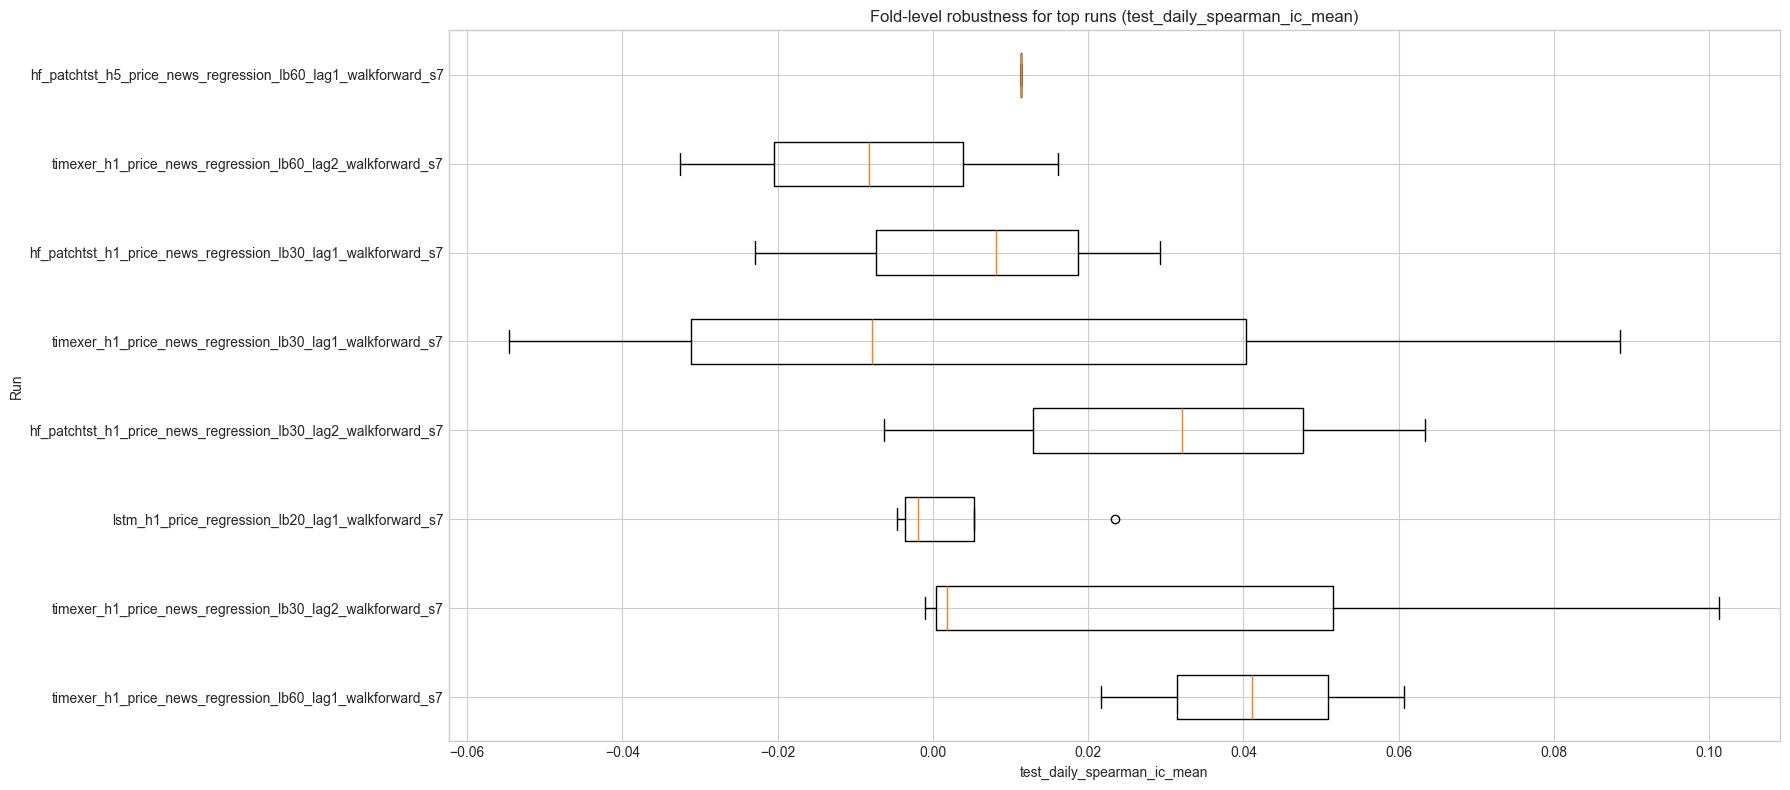

In [6]:
if not folds_df.empty and MAIN_METRIC in folds_df.columns:
    top_run_names = ranked_df.head(min(8, len(ranked_df)))["run_name"].tolist()
    fold_plot_df = analysis_folds_df.loc[analysis_folds_df["run_name"].isin(top_run_names)].copy()

    plt.figure(figsize=(18, 8))
    if HAVE_SEABORN:
        sns.boxplot(data=fold_plot_df, x=MAIN_METRIC, y="run_name", color="#a6cee3")
        sns.stripplot(data=fold_plot_df, x=MAIN_METRIC, y="run_name", color="#1f78b4", size=6, alpha=0.85)
    else:
        grouped = [fold_plot_df.loc[fold_plot_df["run_name"] == name, MAIN_METRIC].dropna().values for name in top_run_names]
        plt.boxplot(grouped, vert=False, labels=top_run_names)
    plt.title(f"Fold-level robustness for top runs ({MAIN_METRIC})")
    plt.xlabel(MAIN_METRIC)
    plt.ylabel("Run")
    plt.tight_layout()
    plt.show()


## Single-Modal vs Bimodal Lift

This section asks whether adding news and sentiment creates a measurable edge over price-only models.

modalities            price  price_news  lift_price_news_minus_price
model_name  horizon                                                 
hf_patchtst 1           NaN      0.0080                          NaN
            5           NaN     -0.0027                          NaN
lightgbm    1       -0.0179         NaN                          NaN
lstm        1        0.0037         NaN                          NaN
timexer     1           NaN      0.0189                          NaN
            5           NaN     -0.0089                          NaN

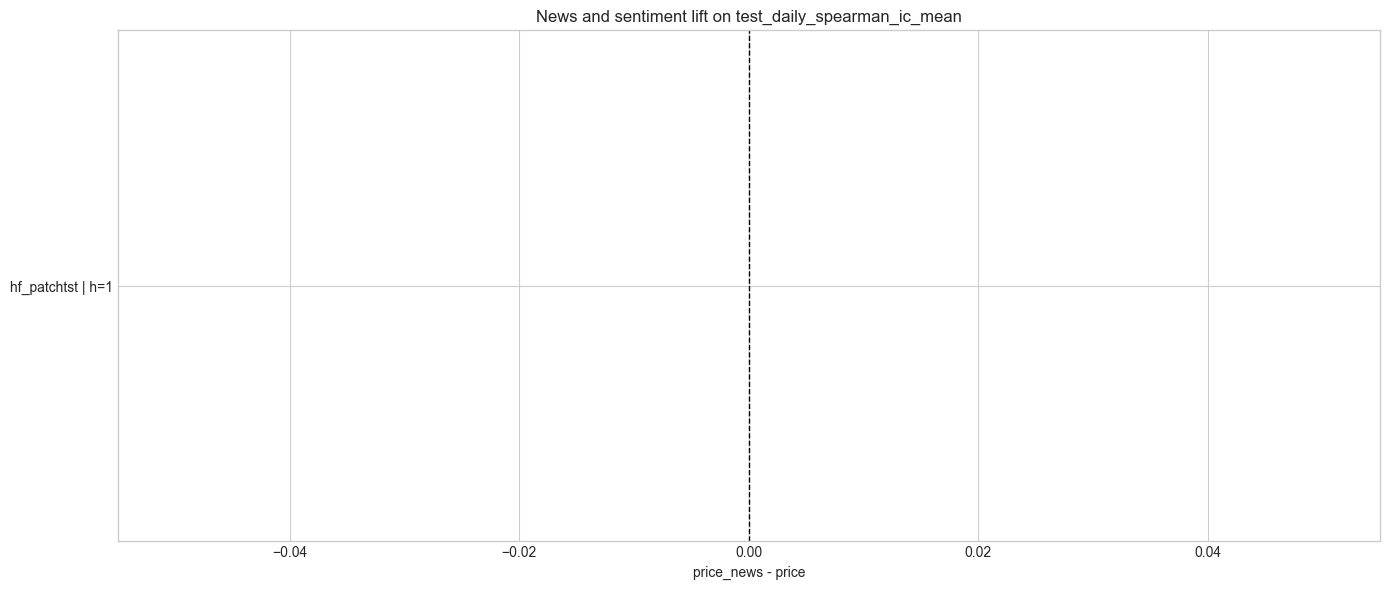

In [7]:
if not runs_df.empty and {"modalities", "model_name", "horizon", MAIN_METRIC}.issubset(ranked_df.columns):
    modality_compare = ranked_df.pivot_table(
        index=["model_name", "horizon"],
        columns="modalities",
        values=MAIN_METRIC,
        aggfunc="mean"
    )
    if {"price", "price_news"}.issubset(modality_compare.columns):
        modality_compare = modality_compare.copy()
        modality_compare["lift_price_news_minus_price"] = modality_compare["price_news"] - modality_compare["price"]
        modality_compare = modality_compare.sort_values("lift_price_news_minus_price", ascending=False)
        display(modality_compare)

        plt.figure(figsize=(14, 6))
        labels = [f"{model} | h={horizon}" for model, horizon in modality_compare.index]
        plt.barh(labels, modality_compare["lift_price_news_minus_price"], color="#33a02c")
        plt.axvline(0.0, color="black", linewidth=1, linestyle="--")
        plt.title(f"News and sentiment lift on {MAIN_METRIC}")
        plt.xlabel("price_news - price")
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("Only one modality is available so far, so lift cannot be computed yet."))


## Best-Run Diagnostics

The next cells drill into the best run and show the kind of evidence that is useful in a competition deck: calibration, cross-sectional ranking quality, cumulative top-bottom spread, and stability over time.

In [8]:
if not runs_df.empty:
    BEST_RUN = MANUAL_BEST_RUN or ranked_df.iloc[0]["run_name"]
    best_run_row = ranked_df.loc[ranked_df["run_name"] == BEST_RUN].iloc[0]
    best_predictions_df = load_predictions_for_run(BEST_RUN, ranked_df)
    best_daily_df, best_ticker_df, best_magnitude_df = build_prediction_diagnostics(best_predictions_df)

    display(Markdown(
        f"### Selected best run: `{BEST_RUN}`  \n"
        f"Model: `{best_run_row['model_name']}` | Modality: `{best_run_row['modalities']}` | Horizon: `{best_run_row['horizon']}` | Lookback: `{best_run_row['lookback']}` | News lag: `{best_run_row.get('news_lag_days', "n/a")}` | Seed: `{best_run_row.get('seed', "n/a")}`"
    ))
    display(best_predictions_df.head())
    display(best_ticker_df.head(15))


### Selected best run: `timexer_h1_price_news_regression_lb60_lag1_walkforward_s7`  
Model: `timexer` | Modality: `price_news` | Horizon: `1` | Lookback: `60` | News lag: `1` | Seed: `7`

,date,ticker,target,prediction,fold,run_name
0,2024-09-18,AAPL,0.0371,0.0004,fold_00,timexer_h1_price_news_regression_lb60_lag1_wal...
1,2024-09-19,AAPL,-0.0029,0.0010,fold_00,timexer_h1_price_news_regression_lb60_lag1_wal...
2,2024-09-20,AAPL,-0.0076,0.0004,fold_00,timexer_h1_price_news_regression_lb60_lag1_wal...
3,2024-09-23,AAPL,0.0040,0.0006,fold_00,timexer_h1_price_news_regression_lb60_lag1_wal...
4,2024-09-24,AAPL,-0.0044,0.0001,fold_00,timexer_h1_price_news_regression_lb60_lag1_wal...


,ticker,observations,mean_abs_error,directional_accuracy,prediction_mean,target_mean
33,JPM,42,0.0112,0.7381,0.0007,0.0044
22,EA,42,0.0085,0.6905,0.0009,0.0034
18,CSCO,42,0.0077,0.6429,0.0006,0.0033
37,LNT,42,0.0108,0.6429,0.0005,0.0006
51,NVDA,42,0.0192,0.6429,0.0010,0.0056
9,BKNG,42,0.0099,0.6190,0.0016,0.0051
25,GOOGL,42,0.0106,0.6190,0.0009,0.0019
15,CMCSA,42,0.0109,0.6190,0.0007,0.0021
60,SCHW,42,0.0121,0.6190,0.0009,0.0059
75,ZM,42,0.0134,0.6190,0.0006,0.0051


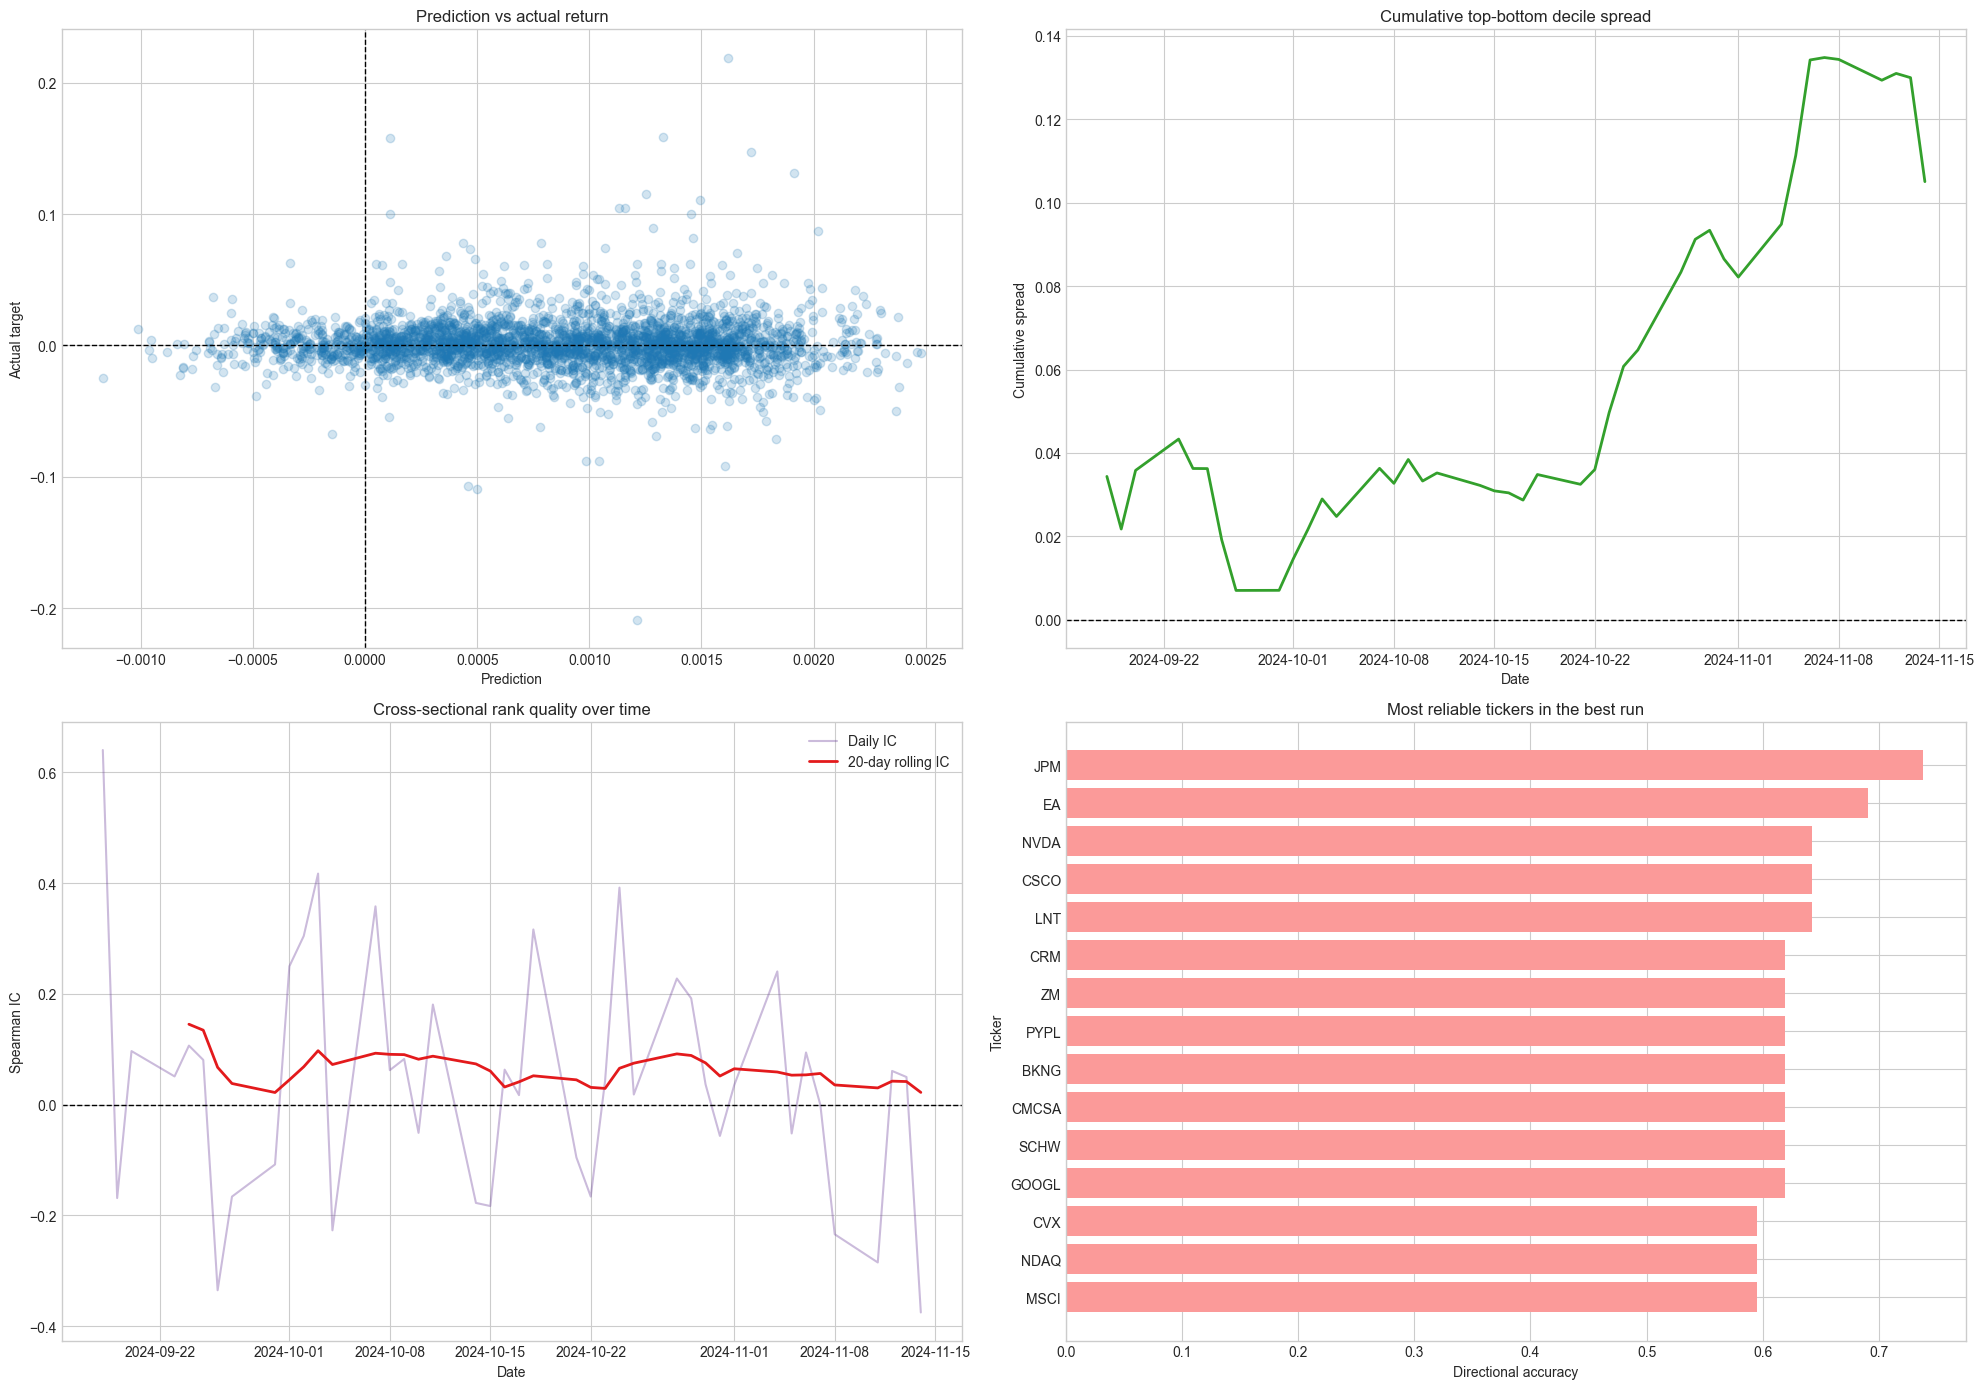

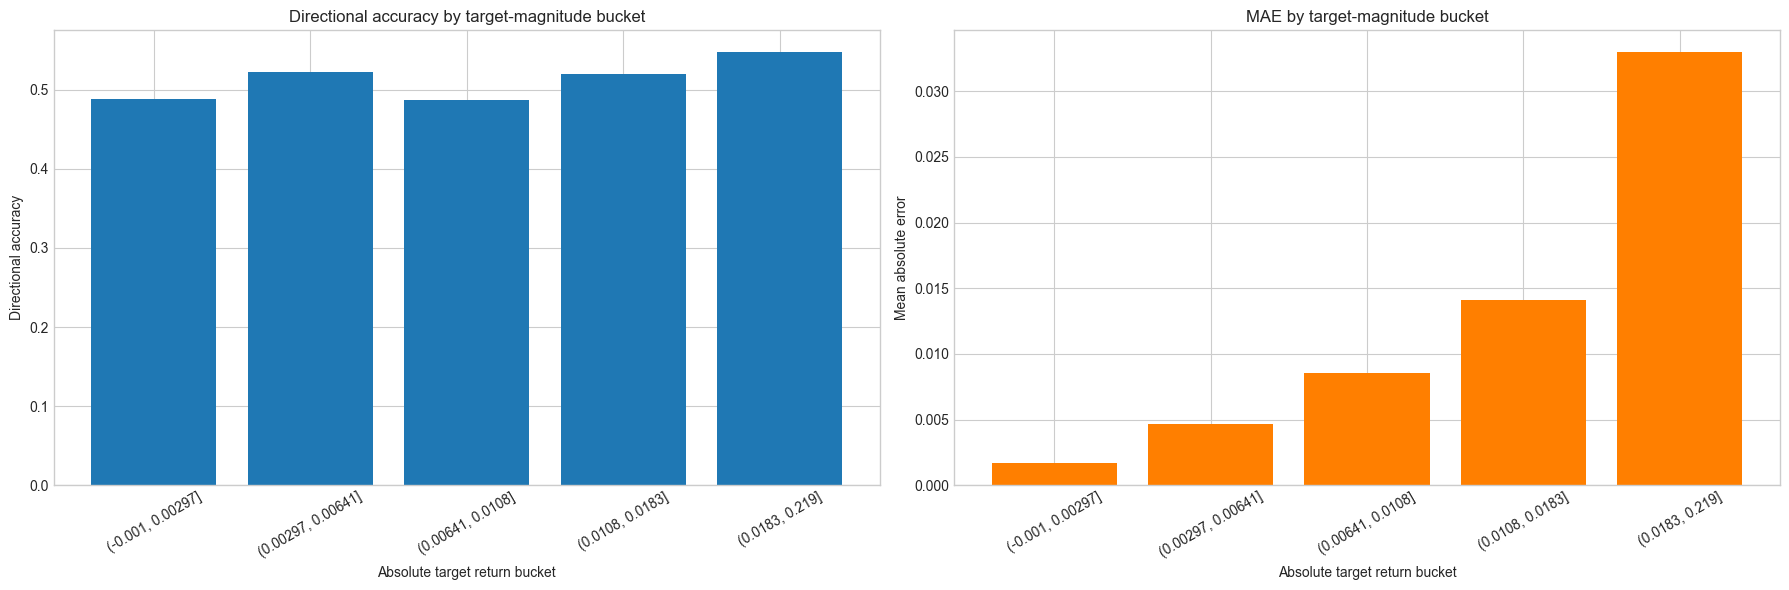

### Stock-history test vs prediction charts

Randomly selected tickers: `MSFT, NTRS, TXN, MRK, TSLA`

In [9]:
if not runs_df.empty and not best_predictions_df.empty:
    sample_df = best_predictions_df.sample(min(5000, len(best_predictions_df)), random_state=7)
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))

    axes[0, 0].scatter(sample_df["prediction"], sample_df["target"], alpha=0.20, color="#1f78b4")
    axes[0, 0].axhline(0.0, color="black", linewidth=1, linestyle="--")
    axes[0, 0].axvline(0.0, color="black", linewidth=1, linestyle="--")
    axes[0, 0].set_title("Prediction vs actual return")
    axes[0, 0].set_xlabel("Prediction")
    axes[0, 0].set_ylabel("Actual target")

    if not best_daily_df.empty:
        axes[0, 1].plot(best_daily_df["date"], best_daily_df["cumulative_spread"], color="#33a02c", linewidth=2)
        axes[0, 1].axhline(0.0, color="black", linewidth=1, linestyle="--")
        axes[0, 1].set_title("Cumulative top-bottom decile spread")
        axes[0, 1].set_xlabel("Date")
        axes[0, 1].set_ylabel("Cumulative spread")

        axes[1, 0].plot(best_daily_df["date"], best_daily_df["daily_ic"], color="#6a3d9a", alpha=0.35, label="Daily IC")
        axes[1, 0].plot(best_daily_df["date"], best_daily_df["rolling_ic_20"], color="#e31a1c", linewidth=2, label="20-day rolling IC")
        axes[1, 0].axhline(0.0, color="black", linewidth=1, linestyle="--")
        axes[1, 0].set_title("Cross-sectional rank quality over time")
        axes[1, 0].set_xlabel("Date")
        axes[1, 0].set_ylabel("Spearman IC")
        axes[1, 0].legend()

    top_tickers = best_ticker_df.head(15).sort_values("directional_accuracy")
    axes[1, 1].barh(top_tickers["ticker"], top_tickers["directional_accuracy"], color="#fb9a99")
    axes[1, 1].set_title("Most reliable tickers in the best run")
    axes[1, 1].set_xlabel("Directional accuracy")
    axes[1, 1].set_ylabel("Ticker")

    plt.tight_layout()
    plt.show()

    if not best_magnitude_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        axes[0].bar(best_magnitude_df["magnitude_bucket"].astype(str), best_magnitude_df["directional_accuracy"], color="#1f78b4")
        axes[0].set_title("Directional accuracy by target-magnitude bucket")
        axes[0].set_xlabel("Absolute target return bucket")
        axes[0].set_ylabel("Directional accuracy")
        axes[0].tick_params(axis="x", rotation=30)

        axes[1].bar(best_magnitude_df["magnitude_bucket"].astype(str), best_magnitude_df["mean_abs_error"], color="#ff7f00")
        axes[1].set_title("MAE by target-magnitude bucket")
        axes[1].set_xlabel("Absolute target return bucket")
        axes[1].set_ylabel("Mean absolute error")
        axes[1].tick_params(axis="x", rotation=30)

        plt.tight_layout()
        plt.show()

    try:
        fig, selected_tickers = plot_random_stock_history_forecasts(
            best_predictions_df,
            price_csv=best_run_row.get("price_csv", "data/dates_on_left_stock_data.csv"),
            horizon=int(best_run_row["horizon"]),
            title="Best run: stock history with actual test prices vs predicted prices for random tickers",
            n_tickers=5,
            seed=7,
        )
        display(Markdown("### Stock-history test vs prediction charts"))
        display(Markdown(f"Randomly selected tickers: `{", ".join(selected_tickers)}`"))
        fig.show()
    except Exception as exc:
        display(Markdown(f"_Stock-history chart unavailable: {exc}_"))


In [10]:
if not runs_df.empty:
    best = ranked_df.iloc[0]
    most_stable = ranked_df.sort_values(f"{MAIN_METRIC}__std", ascending=True).iloc[0] if f"{MAIN_METRIC}__std" in ranked_df.columns else best
    presentation_lines = []
    presentation_lines.append("## Presentation-ready takeaways")
    presentation_lines.append("")
    presentation_lines.append(f"- Best overall run: `{best['run_name']}` using `{best['model_name']}` with `{best['modalities']}` inputs at horizon `{best['horizon']}`, lookback `{best.get('lookback', "n/a")}`, and news lag `{best.get('news_lag_days', "n/a")}`.")
    presentation_lines.append(f"- Main selection metric: `{MAIN_METRIC}` = `{best[MAIN_METRIC]:.4f}` with composite score `{best['composite_score']:.4f}`.")

    if f"{MAIN_METRIC}__std" in ranked_df.columns:
        presentation_lines.append(f"- Most stable run across folds: `{most_stable['run_name']}` with fold std `{most_stable[f'{MAIN_METRIC}__std']:.4f}` on `{MAIN_METRIC}`.")

    if "test_directional_accuracy" in best.index and pd.notna(best.get("test_directional_accuracy", np.nan)):
        presentation_lines.append(f"- Directional hit rate for the best run: `{best['test_directional_accuracy']:.2%}`.")

    if "test_top_bottom_decile_spread" in best.index and pd.notna(best.get("test_top_bottom_decile_spread", np.nan)):
        presentation_lines.append(f"- Portfolio-style separation: top-minus-bottom decile spread = `{best['test_top_bottom_decile_spread']:.4f}`.")

    if 'modality_compare' in globals() and isinstance(modality_compare, pd.DataFrame) and not modality_compare.empty and 'lift_price_news_minus_price' in modality_compare.columns:
        best_lift_row = modality_compare.iloc[0]
        model_name, horizon = best_lift_row.name
        presentation_lines.append(f"- Strongest multimodal gain: `{model_name}` at horizon `{horizon}` improved by `{best_lift_row['lift_price_news_minus_price']:.4f}` when news and sentiment were added.")

    if 'best_daily_df' in globals() and not best_daily_df.empty:
        positive_spread_share = (best_daily_df['top_bottom_spread'] > 0).mean()
        mean_daily_ic = best_daily_df['daily_ic'].mean()
        presentation_lines.append(f"- Best-run time consistency: `{positive_spread_share:.2%}` of evaluation days had positive top-bottom spread, with mean daily IC `{mean_daily_ic:.4f}`.")

    if 'best_ticker_df' in globals() and not best_ticker_df.empty:
        reliable_tickers = ', '.join(best_ticker_df.head(5)['ticker'].tolist())
        presentation_lines.append(f"- Most reliable ticker subset in the best run: `{reliable_tickers}`.")

    presentation_lines.append("")
    presentation_lines.append("### Suggested competition narrative")
    presentation_lines.append("")
    presentation_lines.append("- Start with the leaderboard to show overall model ranking.")
    presentation_lines.append("- Follow with the horizon breakdown to show that model choice changes with prediction window.")
    presentation_lines.append("- Show multimodal lift to justify why news and sentiment matter.")
    presentation_lines.append("- End with cumulative spread and rolling IC to demonstrate that the best model is not only accurate on average, but also usable and stable over time.")

    display(Markdown('\n'.join(presentation_lines)))


## Presentation-ready takeaways

- Best overall run: `timexer_h1_price_news_regression_lb60_lag1_walkforward_s7` using `timexer` with `price_news` inputs at horizon `1`, lookback `60`, and news lag `1`.
- Main selection metric: `test_daily_spearman_ic_mean` = `0.0412` with composite score `6.8025`.
- Most stable run across folds: `hf_patchtst_h5_price_news_regression_lb60_lag1_walkforward_s7` with fold std `0.0000` on `test_daily_spearman_ic_mean`.
- Directional hit rate for the best run: `51.32%`.
- Portfolio-style separation: top-minus-bottom decile spread = `0.0025`.
- Strongest multimodal gain: `hf_patchtst` at horizon `1` improved by `nan` when news and sentiment were added.
- Best-run time consistency: `54.76%` of evaluation days had positive top-bottom spread, with mean daily IC `0.0412`.
- Most reliable ticker subset in the best run: `JPM, EA, CSCO, LNT, NVDA`.

### Suggested competition narrative

- Start with the leaderboard to show overall model ranking.
- Follow with the horizon breakdown to show that model choice changes with prediction window.
- Show multimodal lift to justify why news and sentiment matter.
- End with cumulative spread and rolling IC to demonstrate that the best model is not only accurate on average, but also usable and stable over time.

## Sensitivity Analysis

This section is useful once the broader bash sweep has finished. It shows whether performance is stable across lookback windows and news-lag assumptions, which is often one of the strongest competition arguments because it demonstrates robustness rather than a one-off win.


## Candlestick Overlay View

This adds a market-style chart for the best run: close-derived candlesticks from the stock history, with actual test prices and predicted prices overlaid.


In [11]:
if not runs_df.empty and not best_predictions_df.empty:
    try:
        fig, selected_tickers, note = plot_random_stock_candlestick_forecasts(
            best_predictions_df,
            price_csv=best_run_row.get("price_csv", "data/dates_on_left_stock_data.csv"),
            horizon=int(best_run_row["horizon"]),
            title="Best run: close-derived candlesticks with actual vs predicted test prices",
            n_tickers=5,
            seed=20,
        )
        display(Markdown("### Candlestick-style stock chart"))
        display(Markdown(f"Randomly selected tickers: `{", ".join(selected_tickers)}`"))
        display(Markdown(f"_{note}_"))
        fig.show()
    except Exception as exc:
        display(Markdown(f"_Candlestick chart unavailable: {exc}_"))


### Candlestick-style stock chart

Randomly selected tickers: `CVX, KMB, DIS, TXN, T`

_Candles show pre-test historical price action only. The shaded region is the test window, where the blue line is the actual test price and the orange dashed line is the predicted price. Candles are close-derived because the dataset does not include true OHLC bars._

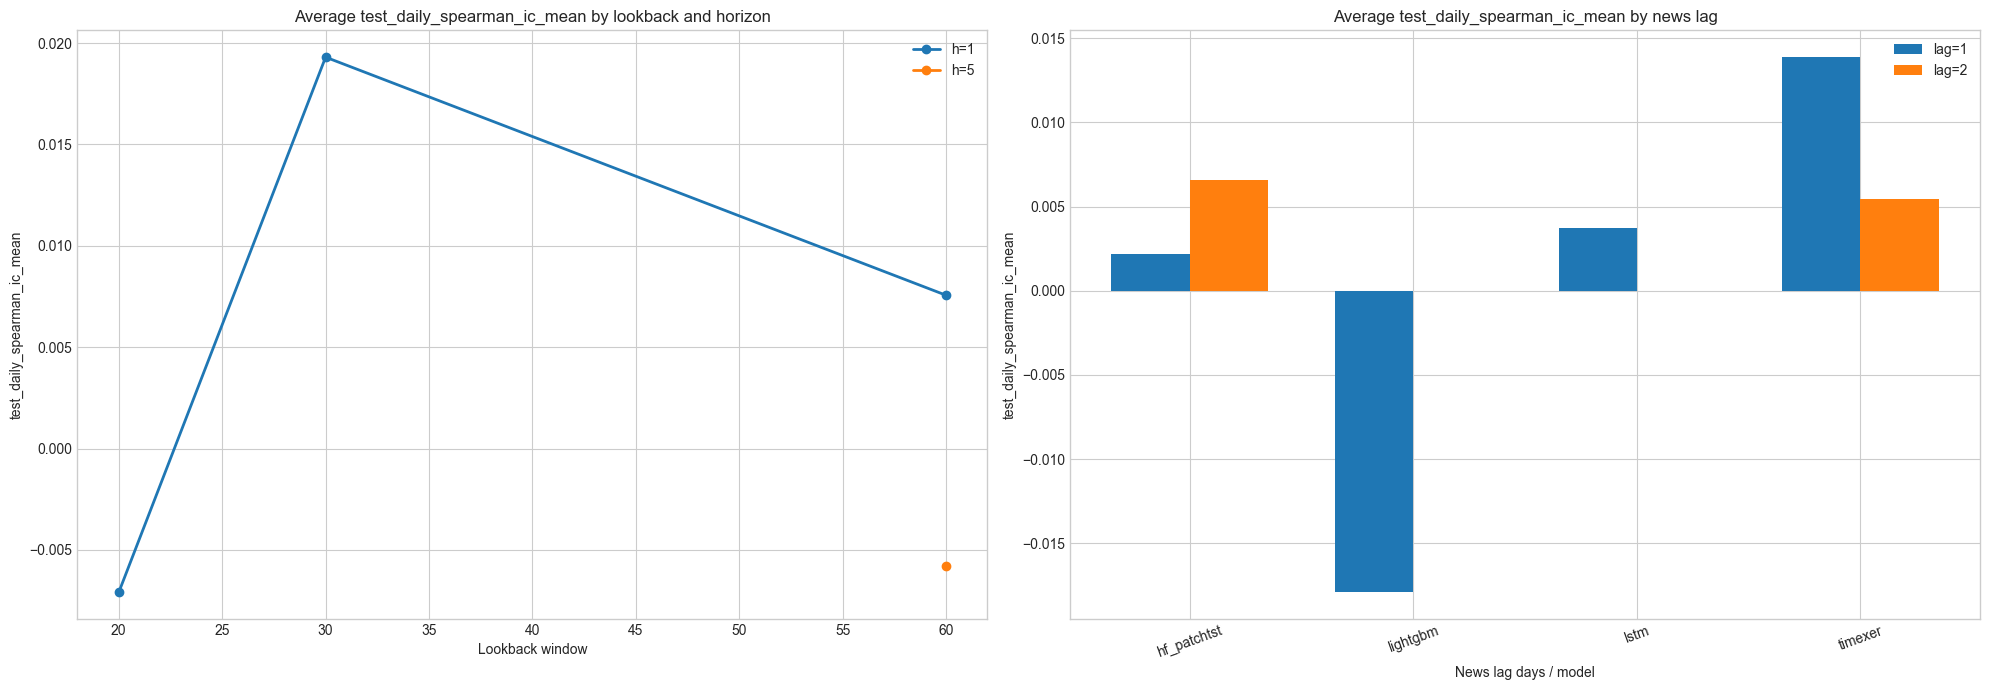

### Top runs with sensitivity metadata

,run_name,model_name,horizon,lookback,news_lag_days,test_daily_spearman_ic_mean,test_daily_spearman_ic_mean__std
0,timexer_h1_price_news_regression_lb60_lag1_wal...,timexer,1,60,1,0.0412,0.0195
1,timexer_h1_price_news_regression_lb30_lag2_wal...,timexer,1,30,2,0.0340,0.0476
2,lstm_h1_price_regression_lb20_lag1_walkforward_s7,lstm,1,20,1,0.0037,0.0115
3,hf_patchtst_h1_price_news_regression_lb30_lag2...,hf_patchtst,1,30,2,0.0297,0.0285
4,timexer_h1_price_news_regression_lb30_lag1_wal...,timexer,1,30,1,0.0087,0.0596
5,hf_patchtst_h1_price_news_regression_lb30_lag1...,hf_patchtst,1,30,1,0.0048,0.0214
6,timexer_h1_price_news_regression_lb60_lag2_wal...,timexer,1,60,2,-0.0083,0.0244
7,hf_patchtst_h5_price_news_regression_lb60_lag1...,hf_patchtst,5,60,1,0.0114,0.0000
8,timexer_h5_price_news_regression_lb60_lag1_wal...,timexer,5,60,1,-0.0082,0.0000
9,lightgbm_h1_price_regression_lb20_lag1_walkfor...,lightgbm,1,20,1,-0.0179,0.0253


In [12]:
if not runs_df.empty and {"lookback", "news_lag_days", MAIN_METRIC}.issubset(ranked_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    lookback_df = ranked_df.groupby(["horizon", "lookback"], as_index=False)[MAIN_METRIC].mean()
    for horizon, group in lookback_df.groupby("horizon"):
        axes[0].plot(group["lookback"], group[MAIN_METRIC], marker="o", linewidth=2, label=f"h={horizon}")
    axes[0].set_title(f"Average {MAIN_METRIC} by lookback and horizon")
    axes[0].set_xlabel("Lookback window")
    axes[0].set_ylabel(MAIN_METRIC)
    axes[0].legend()

    lag_df = ranked_df.groupby(["model_name", "news_lag_days"], as_index=False)[MAIN_METRIC].mean()
    if HAVE_SEABORN:
        sns.barplot(data=lag_df, x="news_lag_days", y=MAIN_METRIC, hue="model_name", ax=axes[1])
    else:
        pivot = lag_df.pivot(index="model_name", columns="news_lag_days", values=MAIN_METRIC).fillna(0.0)
        width = 0.35
        x = np.arange(len(pivot.index))
        for idx, lag in enumerate(pivot.columns):
            axes[1].bar(x + idx * width, pivot[lag].values, width=width, label=f"lag={lag}")
        axes[1].set_xticks(x + width * max(len(pivot.columns) - 1, 0) / 2, labels=pivot.index, rotation=20)
    axes[1].set_title(f"Average {MAIN_METRIC} by news lag")
    axes[1].set_xlabel("News lag days / model")
    axes[1].set_ylabel(MAIN_METRIC)
    axes[1].legend(loc="best")

    plt.tight_layout()
    plt.show()

    stability_cols = [column for column in [MAIN_METRIC, f"{MAIN_METRIC}__std"] if column in ranked_df.columns]
    if stability_cols:
        stability_table = ranked_df[["run_name", "model_name", "horizon", "lookback", "news_lag_days", *stability_cols]].head(20)
        display(Markdown("### Top runs with sensitivity metadata"))
        display(stability_table)
